In [1]:
import torch

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU: True
Tesla T4


In [2]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp

print("Everything imported successfully!")

Everything imported successfully!


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
ZIP_PATH = "/content/drive/MyDrive/dataverse_files.zip"

In [6]:
import zipfile
import os

EXTRACT_DIR = "/content/dataset"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction completed!")

Extraction completed!


In [7]:
print(os.listdir(EXTRACT_DIR))

['magfilo_2024_v1.0.json', '[metadata]_active_observations_url.json', '[metadata]_active_time_intervals.txt']


In [8]:
import os

for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

    if len(files) > 10:
        print(f"{indent}    ... and {len(files) - 10} more files")

dataset/
    magfilo_2024_v1.0.json
    [metadata]_active_observations_url.json
    [metadata]_active_time_intervals.txt


In [9]:
import json

json_path = "/content/dataset/magfilo_2024_v1.0.json"

with open(json_path, "r") as f:
    data = json.load(f)

print("Type of data:", type(data))

if isinstance(data, dict):
    print("\nTop-level keys:")
    for key in data.keys():
        print("-", key)

elif isinstance(data, list):
    print("\nNumber of entries:", len(data))
    print("\nFirst entry:")
    print(data[0])

Type of data: <class 'dict'>

Top-level keys:
- info
- licenses
- images
- annotations
- categories


In [10]:
from pprint import pprint

if isinstance(data, dict):
    for key, value in data.items():
        print("\nKEY:", key)
        print("TYPE:", type(value))

        if isinstance(value, list) and len(value) > 0:
            print("First item:")
            pprint(value[0])
        elif isinstance(value, dict):
            print("First few keys:")
            print(list(value.keys())[:10])
        else:
            print(value)

        print("-" * 80)

elif isinstance(data, list):
    pprint(data[0])


KEY: info
TYPE: <class 'dict'>
First few keys:
['description', 'url', 'version', 'year', 'contributor', 'date_created']
--------------------------------------------------------------------------------

KEY: licenses
TYPE: <class 'dict'>
First few keys:
['url', 'id', 'name']
--------------------------------------------------------------------------------

KEY: images
TYPE: <class 'list'>
First item:
{'date_captured': '2021-06-07 14:23:50',
 'file_name': '20210607142350Bh.jpeg',
 'height': 2048,
 'id': '010103-20210607142350Bh',
 'license': 1,
 'url': 'https://gong2.nso.edu/HA/hag/202106/20210607/20210607142350Bh.jpg',
 'width': 2048}
--------------------------------------------------------------------------------

KEY: annotations
TYPE: <class 'list'>
First item:
{'area': 314.0,
 'bbox': [935.7073, 1410.1032, 8.938800000000015, 48.53189999999995],
 'category_id': 3,
 'id': '03b2a751-8c69-4bde-ba52-bac3de77dc0b',
 'image_id': '010103-20210607142350Bh',
 'iscrowd': 0,
 'segmentation': [[

In [11]:
print("Number of images:", len(data["images"]))
print("Number of annotations:", len(data["annotations"]))
print("Number of categories:", len(data["categories"]))

print("\nCategories:")
for category in data["categories"]:
    print(category)

Number of images: 1593
Number of annotations: 10244
Number of categories: 3

Categories:
{'supercategory': 'filament', 'id': 1, 'name': 'Left'}
{'supercategory': 'filament', 'id': 2, 'name': 'Right'}
{'supercategory': 'filament', 'id': 3, 'name': 'Unidentifiable'}


In [12]:
from collections import Counter

category_counts = Counter(
    annotation["category_id"]
    for annotation in data["annotations"]
)

print("Annotations by category:")

for category_id, count in category_counts.items():
    category_name = next(
        category["name"]
        for category in data["categories"]
        if category["id"] == category_id
    )

    print(
        f"Category {category_id} ({category_name}): {count}"
    )

Annotations by category:
Category 3 (Unidentifiable): 3843
Category 2 (Right): 3273
Category 1 (Left): 3128


In [13]:
image_ids = {
    image["id"]
    for image in data["images"]
}

annotated_image_ids = {
    annotation["image_id"]
    for annotation in data["annotations"]
}

print("Total images:", len(image_ids))
print("Images with annotations:", len(annotated_image_ids))
print("Images without annotations:",
      len(image_ids - annotated_image_ids))

Total images: 1593
Images with annotations: 1439
Images without annotations: 154


In [14]:
from collections import Counter

annotations_per_image = Counter(
    annotation["image_id"]
    for annotation in data["annotations"]
)

print("Maximum annotations in one image:",
      max(annotations_per_image.values()))

print("\nExample images with multiple annotations:")

count = 0

for image_id, number in annotations_per_image.items():

    if number > 1:
        print(image_id, "->", number, "annotations")
        count += 1

    if count >= 10:
        break

Maximum annotations in one image: 26

Example images with multiple annotations:
010103-20210607142350Bh -> 2 annotations
010402-20111222063154Uh -> 11 annotations
010202-20190611032810Mh -> 3 annotations
010203-20160505025554Uh -> 7 annotations
010402-20160920230134Lh -> 8 annotations
010201-20110724164614Mh -> 9 annotations
010403-20111122063134Lh -> 15 annotations
010101-20110327143554Bh -> 7 annotations
010401-20150825082034Lh -> 9 annotations
010401-20150308081954Uh -> 8 annotations


In [15]:
import requests
from PIL import Image
from io import BytesIO
import re

image_info = data["images"][0]

# Get URL from JSON
raw_url = image_info["url"]

# Extract the actual URL from Markdown format
match = re.search(r'\((https?://[^)]+)\)', raw_url)

if match:
    image_url = match.group(1)
else:
    image_url = raw_url

print("Clean URL:")
print(image_url)

try:
    response = requests.get(
        image_url,
        timeout=15
    )

    print("\nStatus code:", response.status_code)
    print("Downloaded bytes:", len(response.content))

except requests.exceptions.Timeout:
    print("\nThe GONG server timed out.")

except requests.exceptions.RequestException as e:
    print("\nDownload failed:")
    print(e)

Clean URL:
https://gong2.nso.edu/HA/hag/202106/20210607/20210607142350Bh.jpg

The GONG server timed out.


In [16]:
import json

metadata_path = "/content/dataset/[metadata]_active_observations_url.json"

with open(metadata_path, "r") as f:
    metadata = json.load(f)

print("Type:", type(metadata))

if isinstance(metadata, dict):
    print("\nTop-level keys:")
    for key in metadata.keys():
        print("-", key)

elif isinstance(metadata, list):
    print("\nNumber of entries:", len(metadata))
    print("\nFirst entry:")
    print(metadata[0])

Type: <class 'dict'>

Top-level keys:
- Mh
- Bh
- Ch
- Th
- Uh
- Lh


In [17]:
from pprint import pprint

if isinstance(metadata, dict):
    for key, value in metadata.items():
        print("\nKEY:", key)
        print("TYPE:", type(value))

        if isinstance(value, list) and len(value) > 0:
            pprint(value[0])
        elif isinstance(value, dict):
            print("Keys:", list(value.keys())[:20])
        else:
            print(value)

        print("-" * 80)

elif isinstance(metadata, list):
    pprint(metadata[0])


KEY: Mh
TYPE: <class 'list'>
{'2011-01-01 17:50:14': {'fits': 'https://gong2.nso.edu/HA/haf/201101/20110101/20110101175014Mh.fits.fz',
                         'ftp': 'ftp://gong2.nso.edu/HA/haf/201101/20110101/20110101175014Mh.fits.fz',
                         'hdr': 'https://gong2.nso.edu/HA/hah/201101/20110101/20110101175014Mh.hdr',
                         'jpeg': ''},
 '2011-01-02 19:32:14': {'fits': 'https://gong2.nso.edu/HA/haf/201101/20110102/20110102193214Mh.fits.fz',
                         'ftp': 'ftp://gong2.nso.edu/HA/haf/201101/20110102/20110102193214Mh.fits.fz',
                         'hdr': 'https://gong2.nso.edu/HA/hah/201101/20110102/20110102193214Mh.hdr',
                         'jpeg': ''},
 '2011-01-03 17:49:14': {'fits': 'https://gong2.nso.edu/HA/haf/201101/20110103/20110103174914Mh.fits.fz',
                         'ftp': 'ftp://gong2.nso.edu/HA/haf/201101/20110103/20110103174914Mh.fits.fz',
                         'hdr': 'https://gong2.nso.edu/HA/hah/201

In [18]:
!pip install -q astropy

In [19]:
from astropy.io import fits
import requests
import re
import os

# Take one observation from the metadata
site = "Mh"

date_key = list(metadata[site][0].keys())[0]
observation = metadata[site][0][date_key]

raw_fits_url = observation["fits"]

# Extract actual URL from Markdown
match = re.search(r'\((https?://[^)]+)\)', raw_fits_url)

if match:
    fits_url = match.group(1)
else:
    fits_url = raw_fits_url

print("Date:", date_key)
print("FITS URL:", fits_url)

Date: 2011-01-01 17:50:14
FITS URL: https://gong2.nso.edu/HA/haf/201101/20110101/20110101175014Mh.fits.fz


In [20]:
try:
    response = requests.get(
        fits_url,
        timeout=20,
        stream=True
    )

    print("Status code:", response.status_code)

    if response.status_code == 200:
        print("Server responded successfully.")
    else:
        print("Server returned:", response.status_code)

except requests.exceptions.Timeout:
    print("❌ FITS server timed out.")

except requests.exceptions.RequestException as e:
    print("❌ Request failed:", e)

❌ FITS server timed out.


In [21]:
!pip install -q kaggle

In [22]:
import os

print(os.path.exists("/content/kaggle.json"))

False


In [23]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.9 MB/s eta 0:00:00


In [24]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Paste your Kaggle API token: ")

Paste your Kaggle API token: ··········


In [25]:
!kaggle datasets list -s magfilo

ref                                                    title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
esairlab/magfilo-v1-0-segmentation-of-solar-filaments  MAGFiLO v1.0 - Segmentation of Solar Filaments   559875805  2026-06-08 17:02:03.230000             86          1  0.8125           


In [26]:
!mkdir -p /content/magfilo
!kaggle datasets download -d esairlab/magfilo-v1-0-segmentation-of-solar-filaments -p /content/magfilo

Dataset URL: https://www.kaggle.com/datasets/esairlab/magfilo-v1-0-segmentation-of-solar-filaments
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 534M/534M [00:09<00:00, 59.7MB/s]



In [27]:
import os

print(os.listdir("/content/magfilo"))

['magfilo-v1-0-segmentation-of-solar-filaments.zip']


In [28]:
import zipfile
import os

zip_files = [
    f for f in os.listdir("/content/magfilo")
    if f.endswith(".zip")
]

print(zip_files)

['magfilo-v1-0-segmentation-of-solar-filaments.zip']


In [29]:
zip_path = "/content/magfilo/" + zip_files[0]
extract_path = "/content/magfilo/data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [30]:
for root, dirs, files in os.walk("/content/magfilo/data"):
    print(root, "->", len(files), "files")
    print(files[:5])

/content/magfilo/data -> 1 files
['MAGFiLO_1.0_Annotations.json']
/content/magfilo/data/MAGFiLO_1.0_Images -> 704 files
['20110923165814Mh.jpeg', '20170328014950Uh.jpeg', '20210701163730Mh.jpeg', '20111011112054Uh.jpeg', '20170415145450Bh.jpeg']


In [31]:
import json

annotation_path = "/content/magfilo/data/MAGFiLO_1.0_Annotations.json"

with open(annotation_path, "r") as f:
    annotations = json.load(f)

print("Type:", type(annotations))

if isinstance(annotations, dict):
    print("Top-level keys:")
    print(annotations.keys())
else:
    print("Number of annotations:", len(annotations))

Type: <class 'dict'>
Top-level keys:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


In [32]:
print("Number of images:", len(annotations["images"]))
print("Number of annotations:", len(annotations["annotations"]))
print("\nCategories:")
print(annotations["categories"])

Number of images: 1143
Number of annotations: 8212

Categories:
[{'supercategory': 'filament', 'id': 1, 'name': 'Left'}, {'supercategory': 'filament', 'id': 2, 'name': 'Right'}, {'supercategory': 'filament', 'id': 3, 'name': 'Unidentifiable'}, {'supercategory': 'filament', 'id': 4, 'name': 'Ambiguous'}]


In [33]:
print("FIRST IMAGE")
print(annotations["images"][0])

print("\nFIRST ANNOTATION")
print(annotations["annotations"][0])

FIRST IMAGE
{'license': 1, 'file_name': '20110203082634Lh.jpeg', 'url': 'https://gong2.nso.edu/HA/hag/201102/20110203/20110203082634Lh.jpg', 'height': 2048, 'width': 2048, 'date_captured': '2011-02-03 08:26:34', 'id': '010102-20110203082634Lh'}

FIRST ANNOTATION
{'segmentation': [[703.0, 644.0, 703.0, 639.0, 699.0, 638.0, 698.0, 637.0, 691.0, 637.0, 690.0, 636.0, 687.1093, 635.2773, 673.736, 635.4775, 667.1391, 633.1747, 663.9929, 630.0285, 662.1357, 629.8342, 660.7687, 628.4672, 660.2863, 626.1832, 661.7966, 622.4266, 661.0929, 620.0, 660.0, 619.0, 652.7955, 620.0, 651.1403, 622.7195, 648.1893, 622.9795, 644.6947, 620.0, 642.9243, 620.0, 639.8859, 618.2708, 629.5132, 617.6658, 626.5541, 621.0695, 626.7145, 622.3265, 629.1189, 625.3979, 626.1782, 627.2039, 623.0655, 626.9815, 618.5582, 625.3875, 617.4135, 624.4652, 617.5685, 622.4102, 614.7768, 621.819, 612.0, 620.0, 609.0, 620.0, 607.0, 618.0, 607.0, 617.0, 604.0, 615.0, 603.0, 613.0, 603.0, 609.0, 602.0, 608.0, 604.0, 605.0, 603.5994

In [34]:
image_info = annotations["images"][0]

image_id = image_info["id"]
image_name = image_info["file_name"]

print("Image name:", image_name)
print("Image ID:", image_id)

image_annotations = [
    ann for ann in annotations["annotations"]
    if ann["image_id"] == image_id
]

print("Number of filaments:", len(image_annotations))

Image name: 20110203082634Lh.jpeg
Image ID: 010102-20110203082634Lh
Number of filaments: 1


Image size: (2048, 2048)


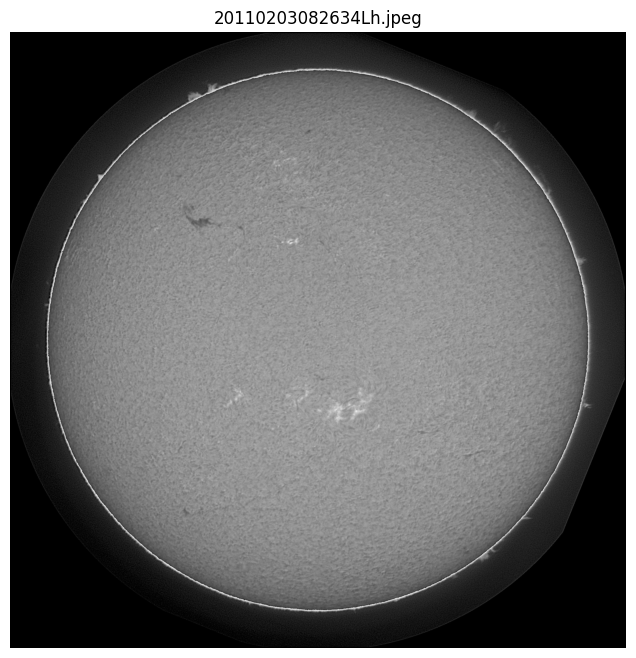

In [35]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = "/content/magfilo/data/MAGFiLO_1.0_Images/" + image_name

img = Image.open(image_path)

print("Image size:", img.size)

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(image_name)
plt.show()

Image size: (2048, 2048)


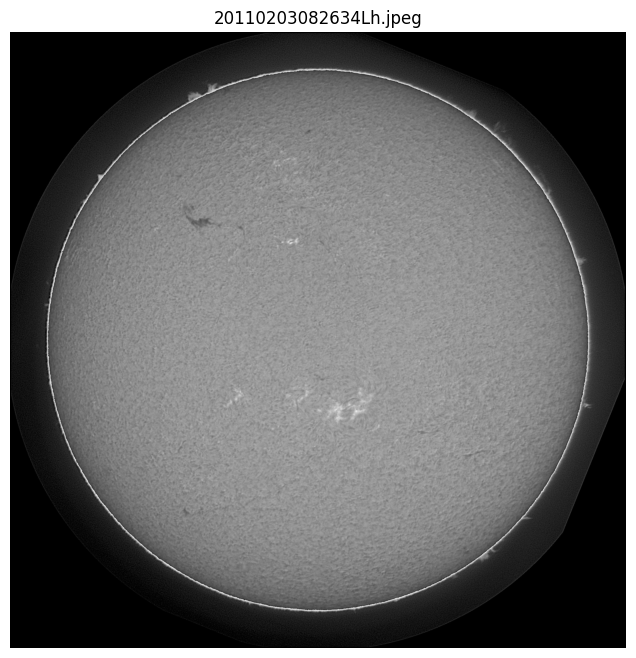

In [36]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = "/content/magfilo/data/MAGFiLO_1.0_Images/" + image_name

img = Image.open(image_path)

print("Image size:", img.size)

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(image_name)
plt.show()

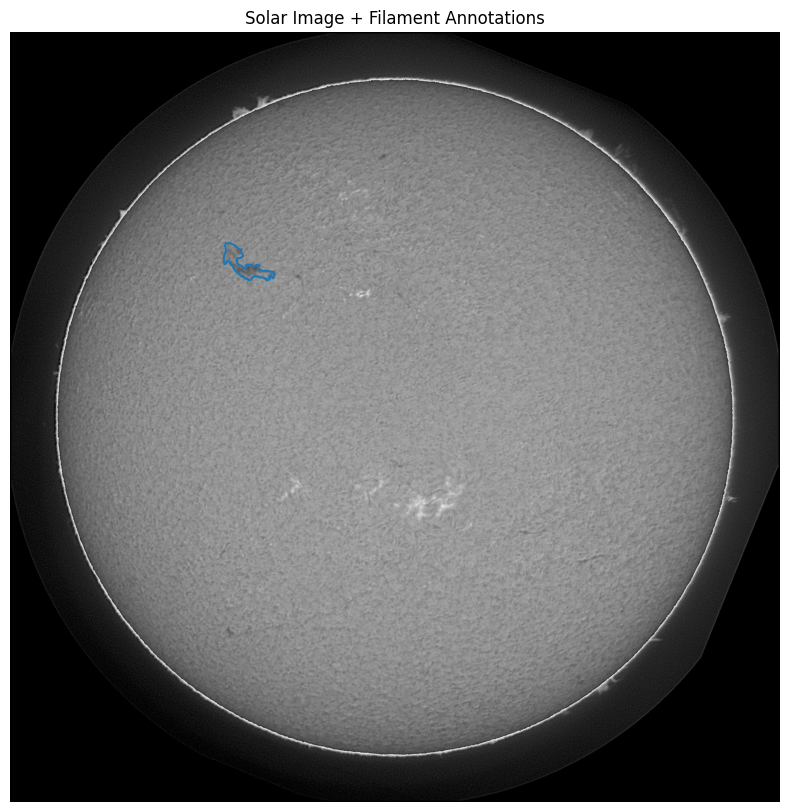

In [37]:
import numpy as np

plt.figure(figsize=(10, 10))

plt.imshow(img, cmap="gray")

for ann in image_annotations:
    segmentation = ann["segmentation"]

    for polygon in segmentation:
        polygon = np.array(polygon).reshape(-1, 2)

        plt.plot(
            polygon[:, 0],
            polygon[:, 1],
            linewidth=1.5
        )

plt.axis("off")
plt.title("Solar Image + Filament Annotations")
plt.show()

In [38]:
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Create a black mask
mask = Image.new("L", img.size, 0)

# Drawing object
draw = ImageDraw.Draw(mask)

# Draw every filament polygon
for ann in image_annotations:
    for polygon in ann["segmentation"]:

        # Convert [x1,y1,x2,y2,...] → [(x1,y1),(x2,y2),...]
        points = [
            (polygon[i], polygon[i + 1])
            for i in range(0, len(polygon), 2)
        ]

        # Fill the filament area with white
        draw.polygon(points, fill=1)

# Convert to NumPy array
mask_array = np.array(mask)

print("Mask shape:", mask_array.shape)
print("Unique values:", np.unique(mask_array))

Mask shape: (2048, 2048)
Unique values: [0 1]


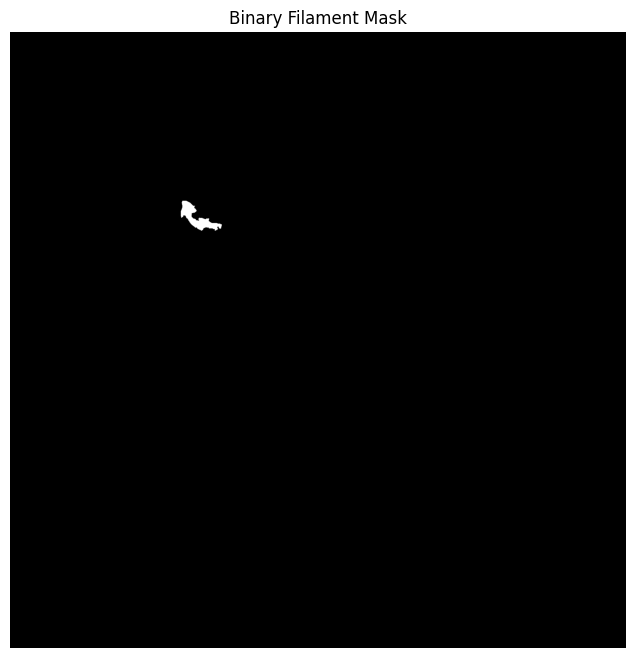

In [39]:
plt.figure(figsize=(8, 8))

plt.imshow(mask_array, cmap="gray")
plt.axis("off")
plt.title("Binary Filament Mask")

plt.show()

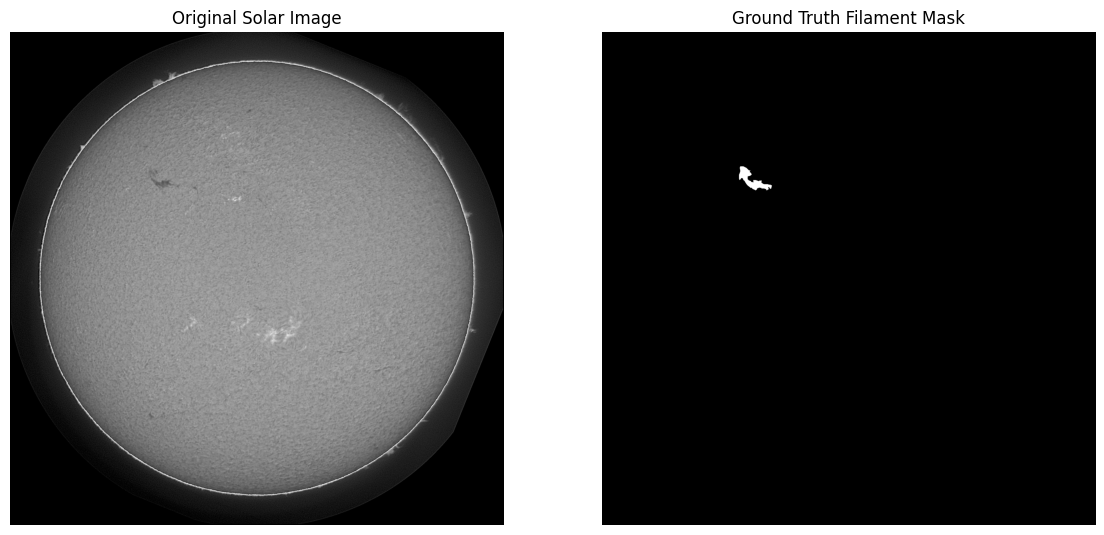

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Original image
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original Solar Image")
axes[0].axis("off")

# Mask
axes[1].imshow(mask_array, cmap="gray")
axes[1].set_title("Ground Truth Filament Mask")
axes[1].axis("off")

plt.show()

In [41]:
import os
import json
import numpy as np
from PIL import Image, ImageDraw
from tqdm import tqdm

# Paths
image_dir = "/content/magfilo/data/MAGFiLO_1.0_Images"
mask_dir = "/content/magfilo/data/MAGFiLO_1.0_Masks"

# Create mask folder
os.makedirs(mask_dir, exist_ok=True)

# --------------------------------------------------
# Create a dictionary:
# image_id → image information
# --------------------------------------------------

image_dict = {
    item["id"]: item
    for item in annotations["images"]
}

# --------------------------------------------------
# Group annotations by image_id
# --------------------------------------------------

annotations_by_image = {}

for ann in annotations["annotations"]:
    image_id = ann["image_id"]

    if image_id not in annotations_by_image:
        annotations_by_image[image_id] = []

    annotations_by_image[image_id].append(ann)

# --------------------------------------------------
# Get the JPEG files that actually exist
# --------------------------------------------------

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Images found:", len(image_files))

# --------------------------------------------------
# Create masks
# --------------------------------------------------

created = 0
skipped = 0

for filename in tqdm(image_files):

    # Find corresponding image information
    matching = [
        item for item in annotations["images"]
        if item["file_name"] == filename
    ]

    if len(matching) == 0:
        skipped += 1
        continue

    image_info = matching[0]
    image_id = image_info["id"]

    width = image_info["width"]
    height = image_info["height"]

    # Black mask
    mask = Image.new("L", (width, height), 0)

    draw = ImageDraw.Draw(mask)

    # Get all filaments for this image
    image_annotations = annotations_by_image.get(image_id, [])

    # Draw every filament
    for ann in image_annotations:

        for polygon in ann["segmentation"]:

            points = [
                (polygon[i], polygon[i + 1])
                for i in range(0, len(polygon), 2)
            ]

            draw.polygon(points, fill=1)

    # Save mask
    mask_filename = os.path.splitext(filename)[0] + ".png"
    mask_path = os.path.join(mask_dir, mask_filename)

    mask.save(mask_path)

    created += 1

print("\nFinished!")
print("Masks created:", created)
print("Skipped:", skipped)
print("Mask folder:", mask_dir)

Images found: 704


100%|██████████| 704/704 [00:27<00:00, 25.24it/s]


Finished!
Masks created: 704
Skipped: 0
Mask folder: /content/magfilo/data/MAGFiLO_1.0_Masks


In [42]:
mask_files = os.listdir(mask_dir)

print("Number of masks:", len(mask_files))
print("First 10 masks:")
print(mask_files[:10])

Number of masks: 704
First 10 masks:
['20110523063154Uh.png', '20140205180154Bh.png', '20210127110130Ch.png', '20111122063134Lh.png', '20170414151450Bh.png', '20160513133714Th.png', '20170805133710Th.png', '20130913142354Bh.png', '20130901073614Th.png', '20200105073250Uh.png']


In [43]:
import os

image_dir = "/content/magfilo/data/MAGFiLO_1.0_Images"
mask_dir = "/content/magfilo/data/MAGFiLO_1.0_Masks"

image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith(".jpeg")
])

pairs = []

for image_file in image_files:

    mask_file = os.path.splitext(image_file)[0] + ".png"
    mask_path = os.path.join(mask_dir, mask_file)

    if os.path.exists(mask_path):
        pairs.append((image_file, mask_file))

print("Total image-mask pairs:", len(pairs))

print("\nFirst 5 pairs:")
for pair in pairs[:5]:
    print(pair)

Total image-mask pairs: 704

First 5 pairs:
('20110114105034Ch.jpeg', '20110114105034Ch.png')
('20110119082634Lh.jpeg', '20110119082634Lh.png')
('20110123174914Mh.jpeg', '20110123174914Mh.png')
('20110128174814Mh.jpeg', '20110128174814Mh.png')
('20110130110334Ch.jpeg', '20110130110334Ch.png')


In [44]:
from sklearn.model_selection import train_test_split

train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.20,
    random_state=42
)

print("Training images:", len(train_pairs))
print("Validation images:", len(val_pairs))

Training images: 563
Validation images: 141


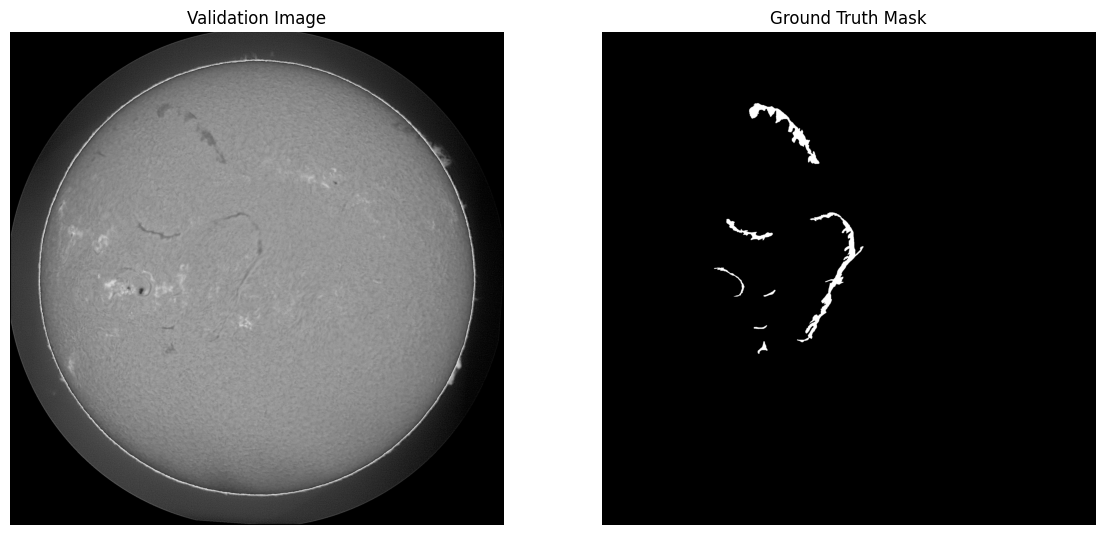

Image: 20150324145954Bh.jpeg
Mask: 20150324145954Bh.png


In [45]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

image_file, mask_file = random.choice(val_pairs)

image = Image.open(os.path.join(image_dir, image_file))
mask = Image.open(os.path.join(mask_dir, mask_file))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Validation Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

plt.show()

print("Image:", image_file)
print("Mask:", mask_file)

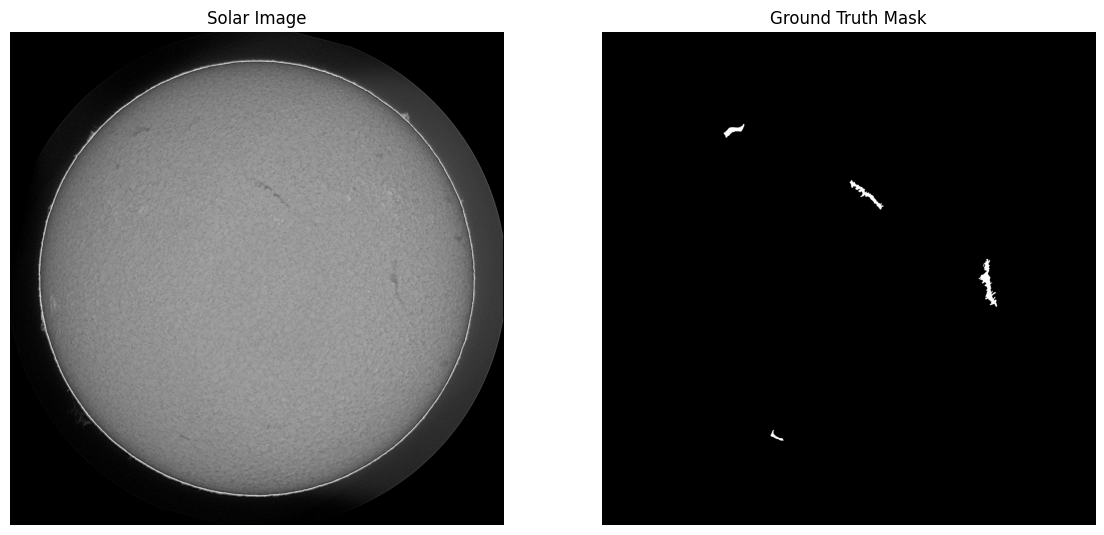

In [46]:
import random
import matplotlib.pyplot as plt
from PIL import Image

filename = random.choice(image_files)

image_path = os.path.join(image_dir, filename)

mask_filename = os.path.splitext(filename)[0] + ".png"
mask_path = os.path.join(mask_dir, mask_filename)

image = Image.open(image_path)
mask = Image.open(mask_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Solar Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

plt.show()

In [47]:
print("Training images:", len(train_pairs))
print("Validation images:", len(val_pairs))

Training images: 563
Validation images: 141


In [48]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os

IMAGE_SIZE = 256


class SolarFilamentDataset(Dataset):

    def __init__(self, pairs, image_dir, mask_dir):
        self.pairs = pairs
        self.image_dir = image_dir
        self.mask_dir = mask_dir

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        image_file, mask_file = self.pairs[idx]

        # Load image
        image_path = os.path.join(self.image_dir, image_file)
        image = Image.open(image_path).convert("L")

        # Load mask
        mask_path = os.path.join(self.mask_dir, mask_file)
        mask = Image.open(mask_path).convert("L")

        # Resize image
        image = image.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.BILINEAR
        )

        # Resize mask
        # NEAREST is important for segmentation masks
        mask = mask.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.NEAREST
        )

        # Convert to NumPy
        image = np.array(image, dtype=np.float32)
        mask = np.array(mask, dtype=np.float32)

        # Normalize image from [0,255] → [0,1]
        image = image / 255.0

        # Make sure mask is binary
        mask = (mask > 0).astype(np.float32)

        # Convert to PyTorch tensors
        # Add channel dimension:
        # [256,256] → [1,256,256]
        image = torch.tensor(image).unsqueeze(0)
        mask = torch.tensor(mask).unsqueeze(0)

        return image, mask

In [49]:
train_dataset = SolarFilamentDataset(
    train_pairs,
    image_dir,
    mask_dir
)

val_dataset = SolarFilamentDataset(
    val_pairs,
    image_dir,
    mask_dir
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 563
Validation samples: 141


In [50]:
image_tensor, mask_tensor = train_dataset[0]

print("Image shape:", image_tensor.shape)
print("Mask shape:", mask_tensor.shape)

print("Image range:",
      image_tensor.min().item(),
      image_tensor.max().item())

print("Mask values:",
      torch.unique(mask_tensor))

Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image range: 0.0 0.800000011920929
Mask values: tensor([0., 1.])


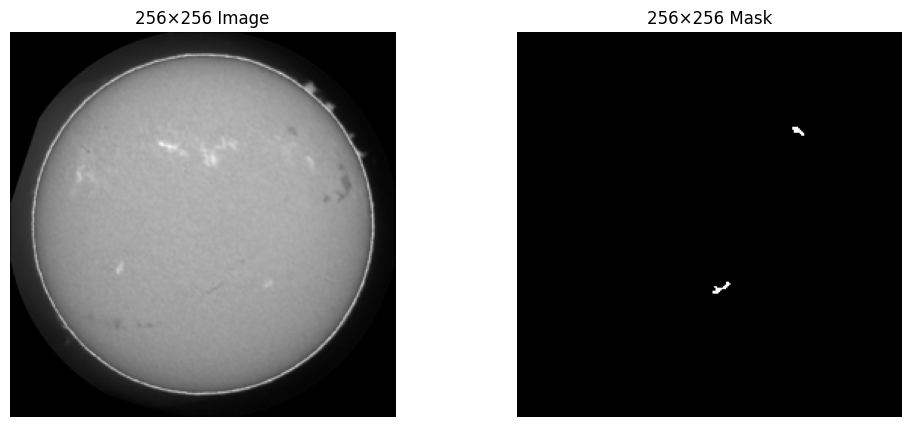

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_tensor.squeeze(), cmap="gray")
plt.title("256×256 Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_tensor.squeeze(), cmap="gray")
plt.title("256×256 Mask")
plt.axis("off")

plt.show()

In [52]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 71
Validation batches: 18


In [53]:
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)

Images: torch.Size([8, 1, 256, 256])
Masks: torch.Size([8, 1, 256, 256])


In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [55]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------

        self.down1 = DoubleConv(1, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # -------------------------
        # Bottleneck
        # -------------------------

        self.bottleneck = DoubleConv(512, 1024)

        # -------------------------
        # Decoder
        # -------------------------

        self.up4 = nn.ConvTranspose2d(
            1024, 512, kernel_size=2, stride=2
        )

        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512, 256, kernel_size=2, stride=2
        )

        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )

        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )

        self.conv1 = DoubleConv(128, 64)

        # Final output
        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        d1 = self.down1(x)

        d2 = self.down2(
            self.pool(d1)
        )

        d3 = self.down3(
            self.pool(d2)
        )

        d4 = self.down4(
            self.pool(d3)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(d4)
        )

        # Decoder
        u4 = self.up4(b)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.conv4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)

In [56]:
model = UNet().to(device)

print(model)

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_si

In [57]:
test_images, test_masks = next(iter(train_loader))

test_images = test_images.to(device)

with torch.no_grad():
    output = model(test_images)

print("Input shape :", test_images.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([8, 1, 256, 256])
Output shape: torch.Size([8, 1, 256, 256])


In [58]:
print("Using device:", device)
print("Input shape :", test_images.shape)
print("Output shape:", output.shape)

Using device: cuda
Input shape : torch.Size([8, 1, 256, 256])
Output shape: torch.Size([8, 1, 256, 256])


In [59]:
import torch
import torch.nn as nn


class DiceLoss(nn.Module):

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):

        # Convert logits → probabilities
        predictions = torch.sigmoid(predictions)

        # Flatten
        predictions = predictions.view(-1)
        targets = targets.view(-1)

        # Dice coefficient
        intersection = (predictions * targets).sum()

        dice = (
            (2.0 * intersection + self.smooth)
            /
            (
                predictions.sum()
                + targets.sum()
                + self.smooth
            )
        )

        # Dice Loss
        return 1 - dice


class BCEDiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, predictions, targets):

        bce_loss = self.bce(predictions, targets)
        dice_loss = self.dice(predictions, targets)

        return bce_loss + dice_loss

In [60]:
criterion = BCEDiceLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEDiceLoss(
  (bce): BCEWithLogitsLoss()
  (dice): DiceLoss()
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [61]:
NUM_EPOCHS = 5

for epoch in range(NUM_EPOCHS):

    # ==========================================
    # TRAINING
    # ==========================================

    model.train()

    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, masks)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # ==========================================
    # VALIDATION
    # ==========================================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/5] Train Loss: 1.3140 Val Loss: 1.2534
Epoch [2/5] Train Loss: 1.2057 Val Loss: 1.1819
Epoch [3/5] Train Loss: 1.1677 Val Loss: 1.1496
Epoch [4/5] Train Loss: 1.1363 Val Loss: 1.1251
Epoch [5/5] Train Loss: 1.1108 Val Loss: 1.1000


In [62]:
import torch

def calculate_metrics(model, loader, device, threshold=0.5):

    model.eval()

    total_intersection = 0
    total_union = 0
    total_tp = 0
    total_fp = 0
    total_fn = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            # Model prediction
            outputs = model(images)

            # Convert logits → probabilities
            probabilities = torch.sigmoid(outputs)

            # Convert probabilities → binary mask
            predictions = (probabilities > threshold).float()

            # True positives
            tp = (predictions * masks).sum().item()

            # False positives
            fp = (predictions * (1 - masks)).sum().item()

            # False negatives
            fn = ((1 - predictions) * masks).sum().item()

            # IoU components
            intersection = tp
            union = tp + fp + fn

            total_tp += tp
            total_fp += fp
            total_fn += fn

            total_intersection += intersection
            total_union += union

    # IoU
    iou = total_intersection / (total_union + 1e-8)

    # Precision
    precision = total_tp / (
        total_tp + total_fp + 1e-8
    )

    # Recall
    recall = total_tp / (
        total_tp + total_fn + 1e-8
    )

    return iou, precision, recall

In [63]:
iou, precision, recall = calculate_metrics(
    model,
    val_loader,
    device
)

print(f"IoU:       {iou:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

IoU:       0.3677
Precision: 0.4886
Recall:    0.5977


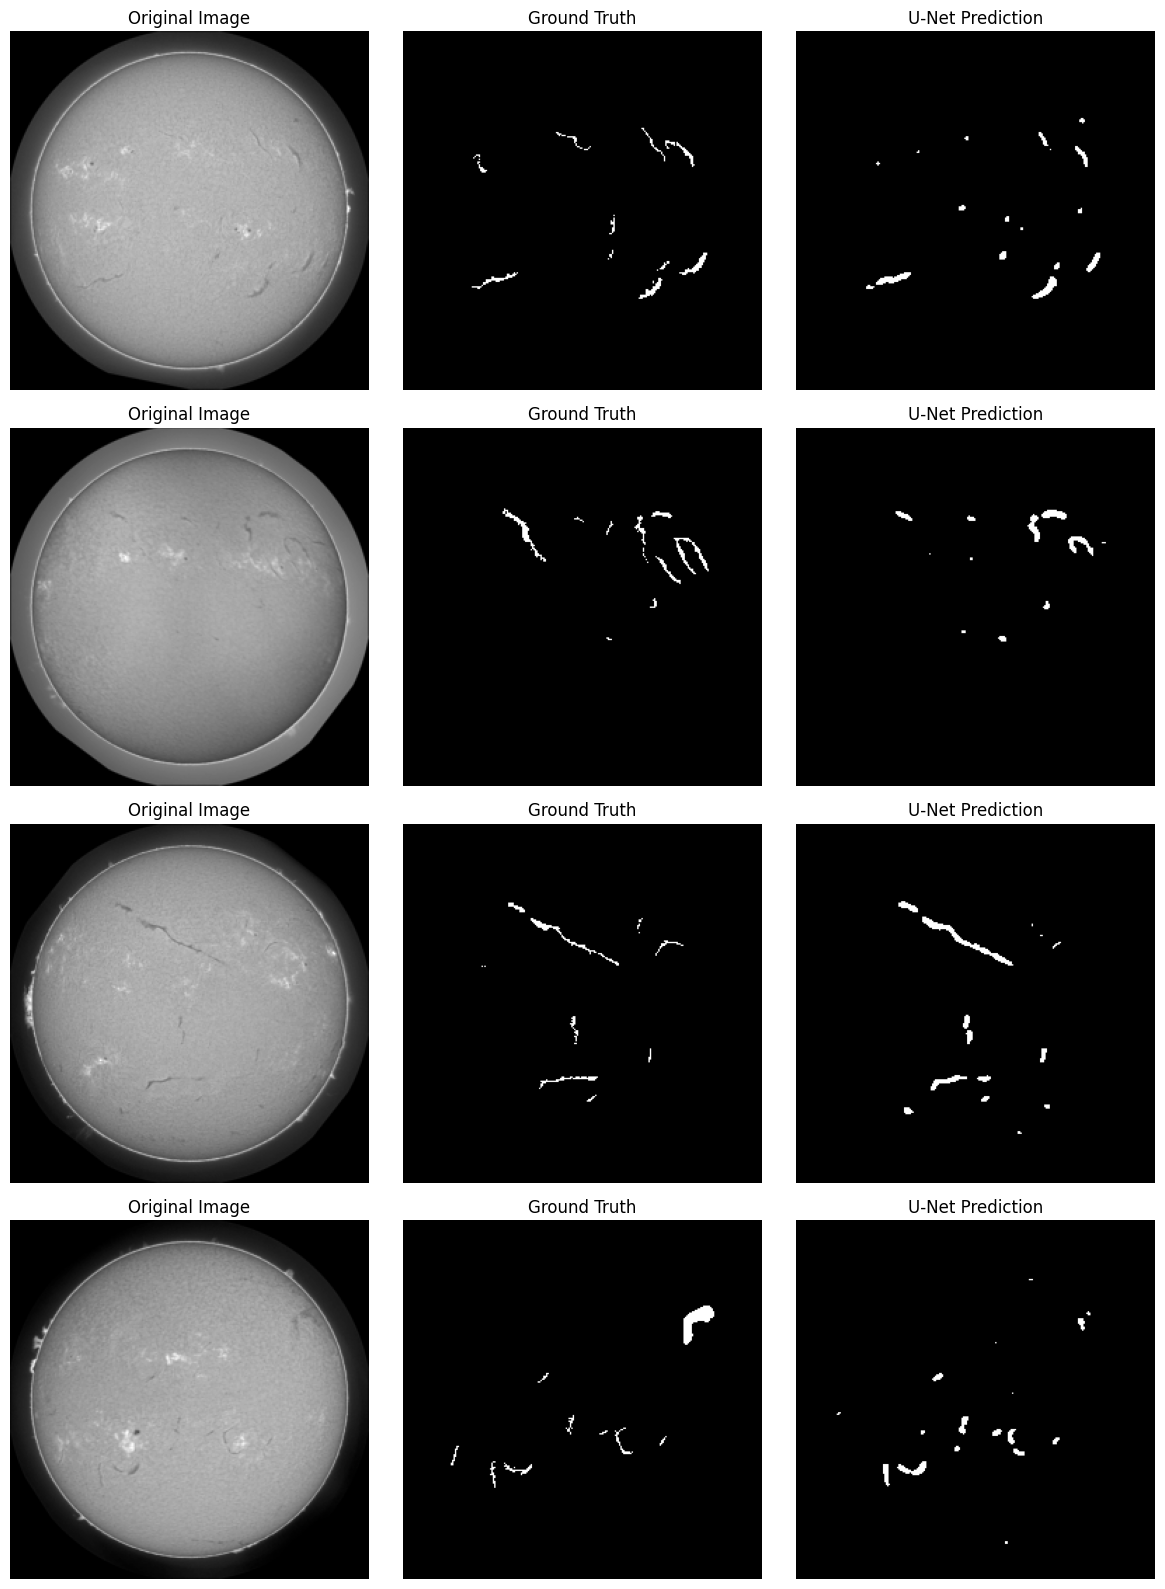

In [64]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(val_loader))

images_gpu = images.to(device)

with torch.no_grad():
    outputs = model(images_gpu)
    probabilities = torch.sigmoid(outputs)

predictions = (probabilities > 0.5).float()

# Show first 4 images
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):

    # Original
    axes[i, 0].imshow(
        images[i].squeeze(),
        cmap="gray"
    )
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    # Ground truth
    axes[i, 1].imshow(
        masks[i].squeeze(),
        cmap="gray"
    )
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    # Prediction
    axes[i, 2].imshow(
        predictions[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[i, 2].set_title("U-Net Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [65]:
NUM_MORE_EPOCHS = 15

for epoch in range(NUM_MORE_EPOCHS):

    # ==============================
    # TRAIN
    # ==============================

    model.train()

    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # ==============================
    # VALIDATION
    # ==============================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)


    print(
        f"Epoch [{epoch+6}/20] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [6/20] Train Loss: 1.0880 Val Loss: 1.0733
Epoch [7/20] Train Loss: 1.0665 Val Loss: 1.0527
Epoch [8/20] Train Loss: 1.0462 Val Loss: 1.0306
Epoch [9/20] Train Loss: 1.0258 Val Loss: 1.0261
Epoch [10/20] Train Loss: 1.0066 Val Loss: 0.9908
Epoch [11/20] Train Loss: 0.9858 Val Loss: 0.9657
Epoch [12/20] Train Loss: 0.9648 Val Loss: 0.9563
Epoch [13/20] Train Loss: 0.9423 Val Loss: 0.9301
Epoch [14/20] Train Loss: 0.9179 Val Loss: 0.8990
Epoch [15/20] Train Loss: 0.8910 Val Loss: 0.8659
Epoch [16/20] Train Loss: 0.8591 Val Loss: 0.8351
Epoch [17/20] Train Loss: 0.8184 Val Loss: 0.8129
Epoch [18/20] Train Loss: 0.7759 Val Loss: 0.7693
Epoch [19/20] Train Loss: 0.7275 Val Loss: 0.7217
Epoch [20/20] Train Loss: 0.6751 Val Loss: 0.6823


In [66]:
iou, precision, recall = calculate_metrics(
    model,
    val_loader,
    device
)

print("========== BASELINE U-NET ==========")
print(f"IoU:       {iou:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

========== BASELINE U-NET ==========
IoU:       0.4602
Precision: 0.5930
Recall:    0.6726


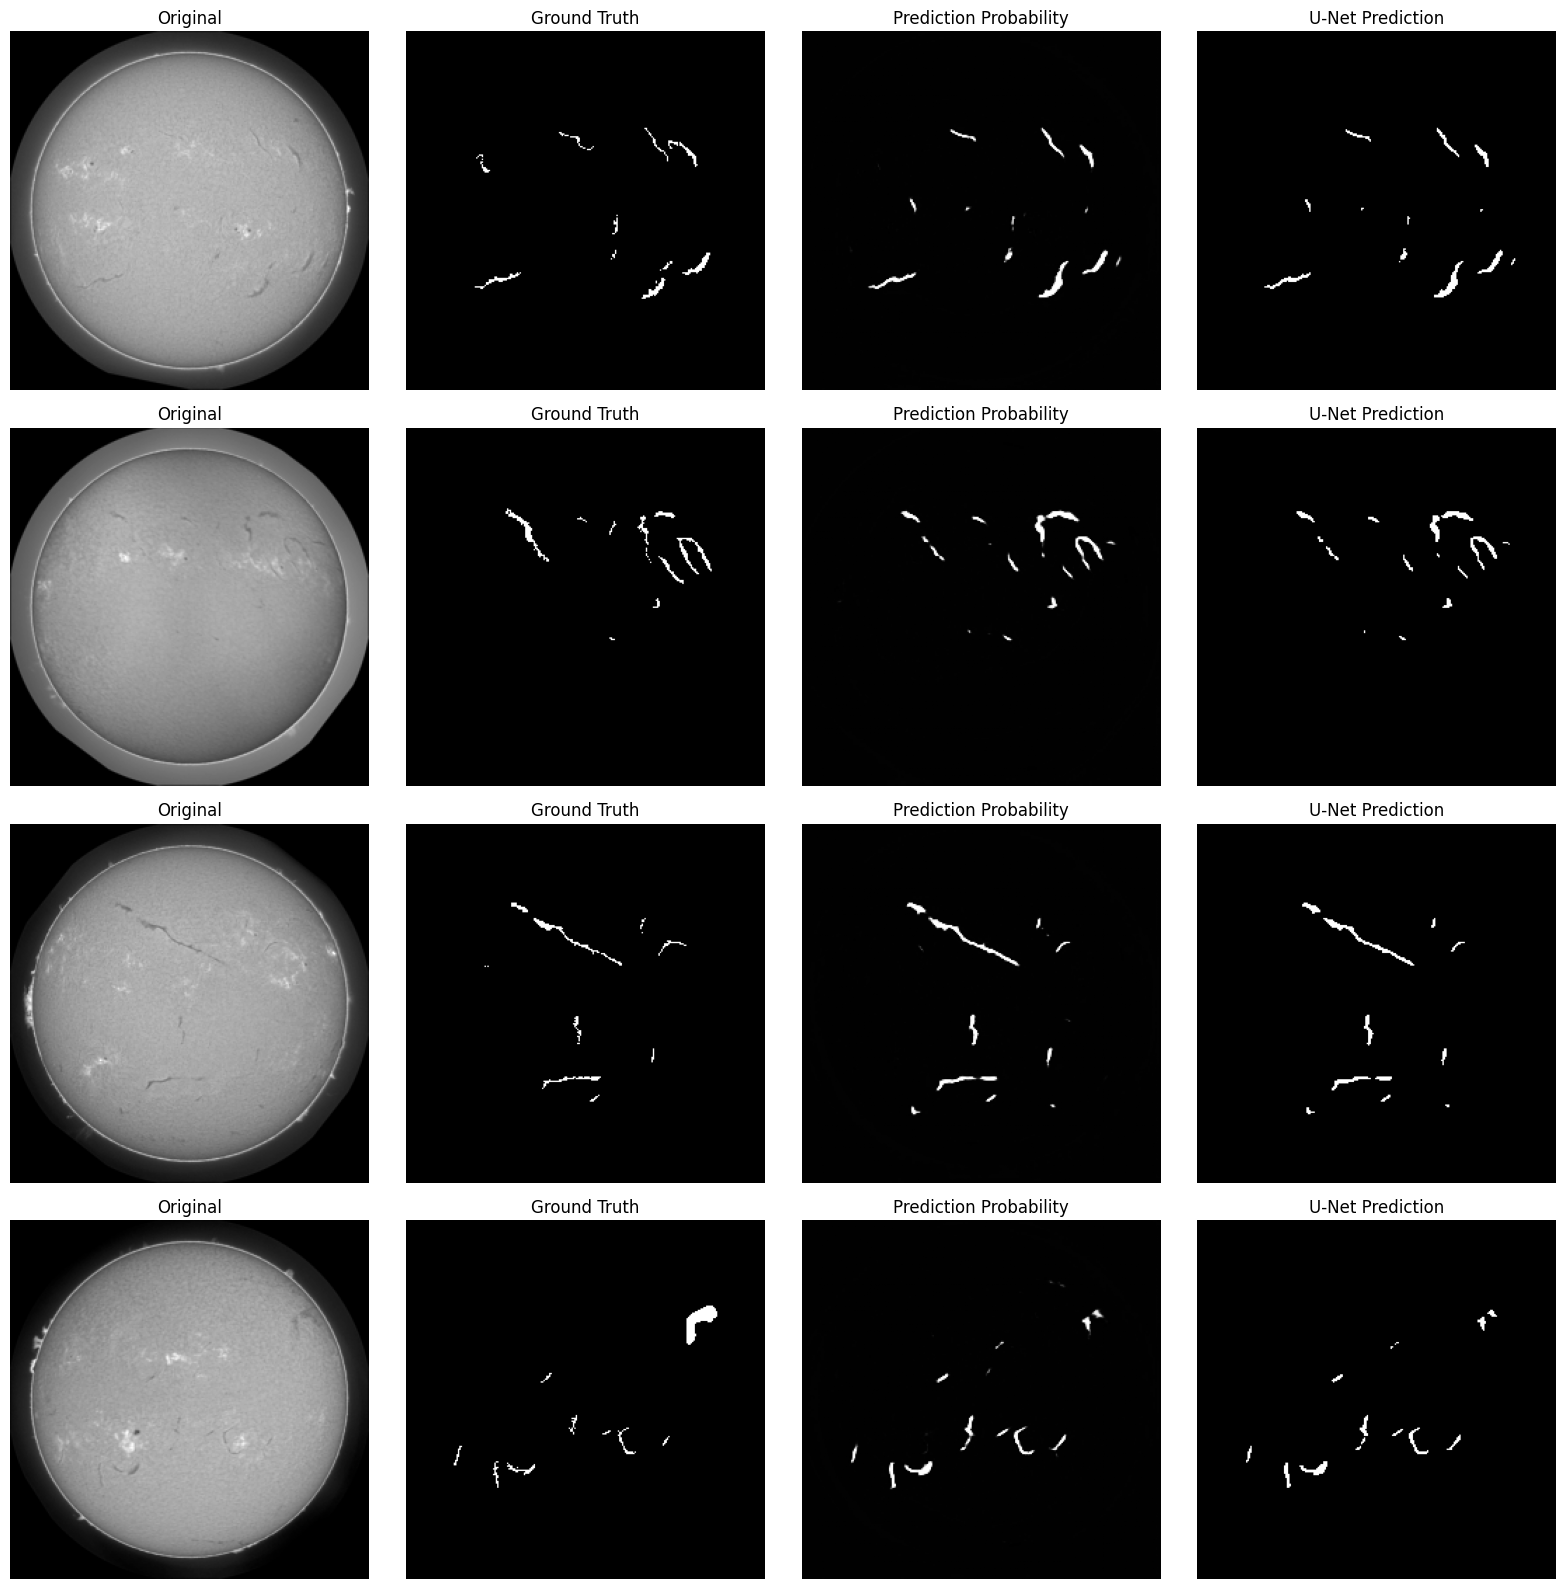

In [67]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(val_loader))

images_gpu = images.to(device)

with torch.no_grad():
    outputs = model(images_gpu)
    probabilities = torch.sigmoid(outputs)

predictions = (probabilities > 0.5).float()


fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i in range(4):

    # Original
    axes[i, 0].imshow(
        images[i].squeeze(),
        cmap="gray"
    )
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # Ground truth
    axes[i, 1].imshow(
        masks[i].squeeze(),
        cmap="gray"
    )
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    # Probability
    axes[i, 2].imshow(
        probabilities[i].cpu().squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[i, 2].set_title("Prediction Probability")
    axes[i, 2].axis("off")

    # Binary prediction
    axes[i, 3].imshow(
        predictions[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[i, 3].set_title("U-Net Prediction")
    axes[i, 3].axis("off")


plt.tight_layout()
plt.show()

In [68]:
torch.save(
    model.state_dict(),
    "/content/baseline_unet.pth"
)

print("Baseline model saved!")

Baseline model saved!


In [69]:
import os

print(
    "File exists:",
    os.path.exists("/content/baseline_unet.pth")
)

print(
    "File size:",
    os.path.getsize("/content/baseline_unet.pth") / (1024**2),
    "MB"
)

File exists: True
File size: 118.5061674118042 MB


In [70]:
baseline_results = {
    "IoU": iou,
    "Precision": precision,
    "Recall": recall
}

print(baseline_results)

{'IoU': 0.4601712117199788, 'Precision': 0.5929674528622392, 'Recall': 0.6726437730589869}


In [71]:
import json

with open("/content/baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=4)

print("Baseline results saved!")

Baseline results saved!


In [72]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class EdgeLoss(nn.Module):

    def __init__(self):
        super().__init__()

        # Sobel filters
        sobel_x = torch.tensor(
            [[-1, 0, 1],
             [-2, 0, 2],
             [-1, 0, 1]],
            dtype=torch.float32
        ).view(1, 1, 3, 3)

        sobel_y = torch.tensor(
            [[-1, -2, -1],
             [ 0,  0,  0],
             [ 1,  2,  1]],
            dtype=torch.float32
        ).view(1, 1, 3, 3)

        self.register_buffer("sobel_x", sobel_x)
        self.register_buffer("sobel_y", sobel_y)


    def forward(self, predictions, targets):

        # Convert prediction logits to probabilities
        predictions = torch.sigmoid(predictions)

        # Prediction edges
        pred_x = F.conv2d(
            predictions,
            self.sobel_x,
            padding=1
        )

        pred_y = F.conv2d(
            predictions,
            self.sobel_y,
            padding=1
        )

        pred_edges = torch.sqrt(
            pred_x ** 2 + pred_y ** 2 + 1e-8
        )


        # Ground-truth edges
        target_x = F.conv2d(
            targets,
            self.sobel_x,
            padding=1
        )

        target_y = F.conv2d(
            targets,
            self.sobel_y,
            padding=1
        )

        target_edges = torch.sqrt(
            target_x ** 2 + target_y ** 2 + 1e-8
        )


        # Compare edges
        return F.l1_loss(
            pred_edges,
            target_edges
        )

In [73]:
class EdgeAwareLoss(nn.Module):

    def __init__(self, edge_weight=0.1):

        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.edge = EdgeLoss()

        self.edge_weight = edge_weight


    def forward(self, predictions, targets):

        bce_loss = self.bce(
            predictions,
            targets
        )

        dice_loss = self.dice(
            predictions,
            targets
        )

        edge_loss = self.edge(
            predictions,
            targets
        )

        total_loss = (
            bce_loss
            + dice_loss
            + self.edge_weight * edge_loss
        )

        return total_loss

In [74]:
improved_model = UNet().to(device)

improved_criterion = EdgeAwareLoss(
    edge_weight=0.1
).to(device)

improved_optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=1e-4
)

print("Improved model created.")
print("Model device:", next(improved_model.parameters()).device)
print("Loss device:", improved_criterion.edge.sobel_x.device)

Improved model created.
Model device: cuda:0
Loss device: cuda:0


In [75]:
test_images, test_masks = next(iter(train_loader))

test_images = test_images.to(device)
test_masks = test_masks.to(device)

with torch.no_grad():

    test_outputs = improved_model(test_images)

    test_loss = improved_criterion(
        test_outputs,
        test_masks
    )

print("Test loss:", test_loss.item())

Test loss: 1.504522681236267


In [76]:
NUM_EPOCHS = 20

improved_train_losses = []
improved_val_losses = []

for epoch in range(NUM_EPOCHS):

    # ==========================================
    # TRAINING
    # ==========================================

    improved_model.train()

    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        improved_optimizer.zero_grad()

        outputs = improved_model(images)

        loss = improved_criterion(
            outputs,
            masks
        )

        loss.backward()

        improved_optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    improved_train_losses.append(train_loss)


    # ==========================================
    # VALIDATION
    # ==========================================

    improved_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = improved_model(images)

            loss = improved_criterion(
                outputs,
                masks
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)

    improved_val_losses.append(val_loss)


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/20] Train Loss: 1.2537 Val Loss: 1.1731
Epoch [2/20] Train Loss: 1.1651 Val Loss: 1.1387
Epoch [3/20] Train Loss: 1.1245 Val Loss: 1.1095
Epoch [4/20] Train Loss: 1.0938 Val Loss: 1.0816
Epoch [5/20] Train Loss: 1.0657 Val Loss: 1.0484
Epoch [6/20] Train Loss: 1.0401 Val Loss: 1.0267
Epoch [7/20] Train Loss: 1.0152 Val Loss: 1.0032
Epoch [8/20] Train Loss: 0.9918 Val Loss: 0.9742
Epoch [9/20] Train Loss: 0.9671 Val Loss: 0.9578
Epoch [10/20] Train Loss: 0.9405 Val Loss: 0.9335
Epoch [11/20] Train Loss: 0.9100 Val Loss: 0.8961
Epoch [12/20] Train Loss: 0.8740 Val Loss: 0.8537
Epoch [13/20] Train Loss: 0.8357 Val Loss: 0.8213
Epoch [14/20] Train Loss: 0.7944 Val Loss: 0.7712
Epoch [15/20] Train Loss: 0.7420 Val Loss: 0.7206
Epoch [16/20] Train Loss: 0.6855 Val Loss: 0.6782
Epoch [17/20] Train Loss: 0.6320 Val Loss: 0.6092
Epoch [18/20] Train Loss: 0.5710 Val Loss: 0.5953
Epoch [19/20] Train Loss: 0.5197 Val Loss: 0.5572
Epoch [20/20] Train Loss: 0.4731 Val Loss: 0.5002


In [77]:
improved_iou, improved_precision, improved_recall = calculate_metrics(
    improved_model,
    val_loader,
    device
)

print("========== EDGE-AWARE U-NET ==========")
print(f"IoU:       {improved_iou:.4f}")
print(f"Precision: {improved_precision:.4f}")
print(f"Recall:    {improved_recall:.4f}")

========== EDGE-AWARE U-NET ==========
IoU:       0.4671
Precision: 0.6228
Recall:    0.6513


In [78]:
print("\n========== COMPARISON ==========")

print(f"{'Metric':<12} {'Baseline':>10} {'Edge-Aware':>12}")

print(
    f"{'IoU':<12} "
    f"{iou:>10.4f} "
    f"{improved_iou:>12.4f}"
)

print(
    f"{'Precision':<12} "
    f"{precision:>10.4f} "
    f"{improved_precision:>12.4f}"
)

print(
    f"{'Recall':<12} "
    f"{recall:>10.4f} "
    f"{improved_recall:>12.4f}"
)


========== COMPARISON ==========
Metric         Baseline   Edge-Aware
IoU              0.4602       0.4671
Precision        0.5930       0.6228
Recall           0.6726       0.6513


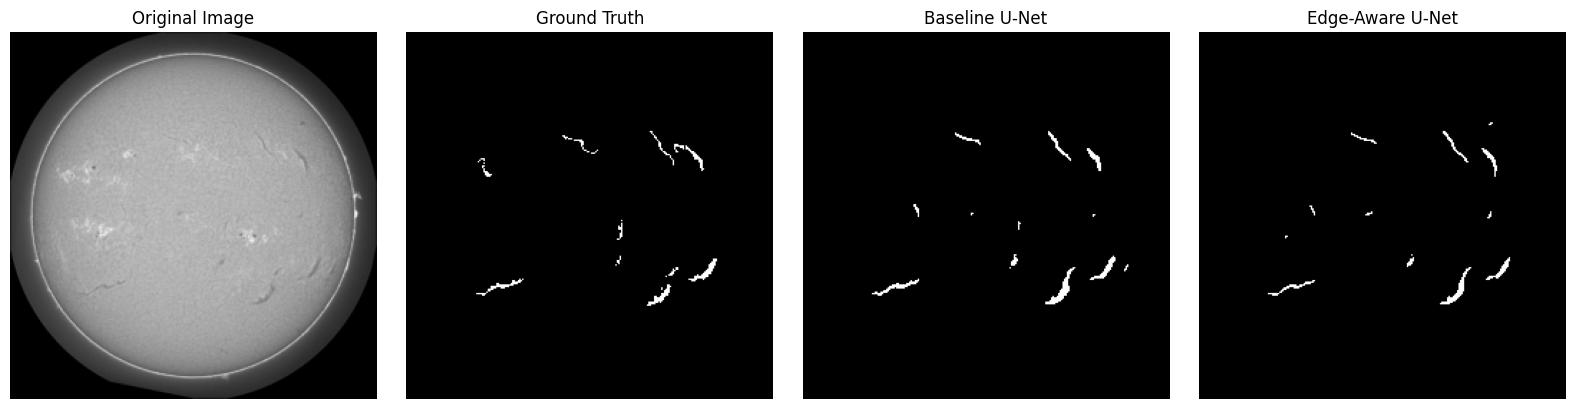

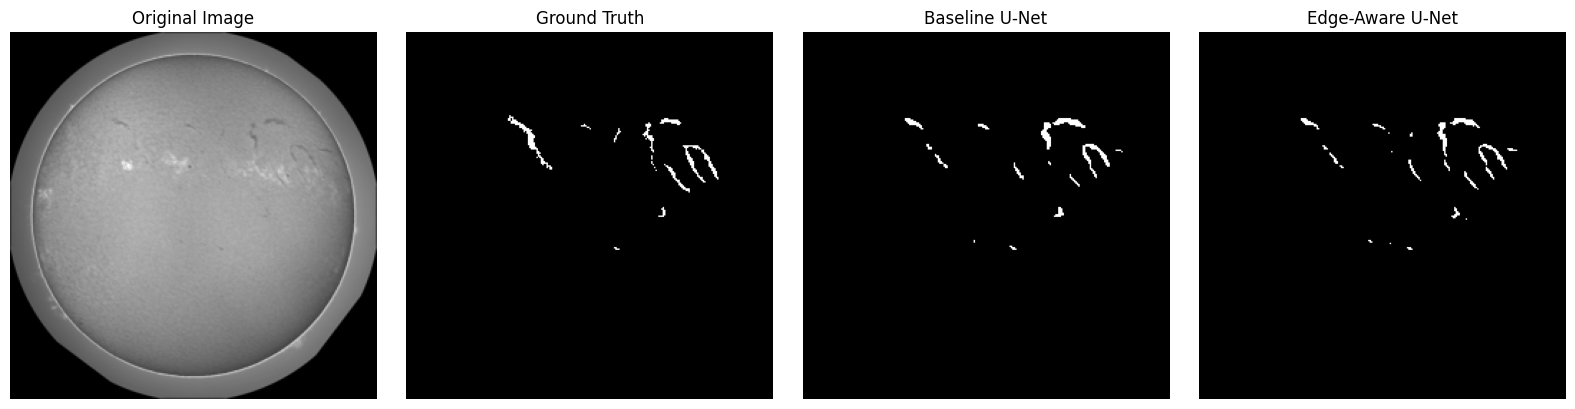

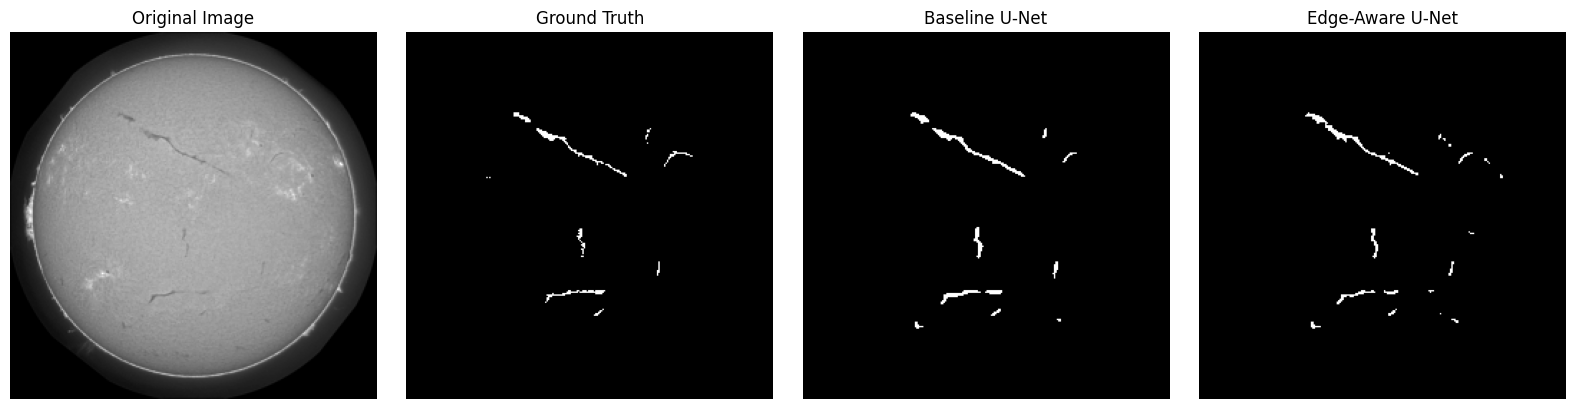

In [79]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Take one batch from validation set
images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

# Predictions from both models
with torch.no_grad():
    baseline_outputs = model(images)
    improved_outputs = improved_model(images)

baseline_preds = (torch.sigmoid(baseline_outputs) > 0.5).float()
improved_preds = (torch.sigmoid(improved_outputs) > 0.5).float()

# Show first 3 examples
for i in range(3):

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(images[i, 0].cpu(), cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(masks[i, 0].cpu(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(baseline_preds[i, 0].cpu(), cmap="gray")
    plt.title("Baseline U-Net")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(improved_preds[i, 0].cpu(), cmap="gray")
    plt.title("Edge-Aware U-Net")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [80]:
# Save Edge-Aware U-Net
torch.save(
    improved_model.state_dict(),
    "/content/edge_aware_unet.pth"
)

# Save its results
improved_results = {
    "IoU": improved_iou,
    "Precision": improved_precision,
    "Recall": improved_recall
}

with open("/content/edge_aware_results.json", "w") as f:
    json.dump(improved_results, f, indent=4)

print("Edge-Aware model saved!")
print("Results saved!")

Edge-Aware model saved!
Results saved!


In [81]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("========== THRESHOLD TUNING ==========")

for threshold in thresholds:
    test_iou, test_precision, test_recall = calculate_metrics(
        improved_model,
        val_loader,
        device,
        threshold=threshold
    )

    print(
        f"Threshold: {threshold:.1f} | "
        f"IoU: {test_iou:.4f} | "
        f"Precision: {test_precision:.4f} | "
        f"Recall: {test_recall:.4f}"
    )

========== THRESHOLD TUNING ==========
Threshold: 0.3 | IoU: 0.4601 | Precision: 0.5902 | Recall: 0.6761
Threshold: 0.4 | IoU: 0.4641 | Precision: 0.6074 | Recall: 0.6630
Threshold: 0.5 | IoU: 0.4671 | Precision: 0.6228 | Recall: 0.6513
Threshold: 0.6 | IoU: 0.4684 | Precision: 0.6369 | Recall: 0.6390
Threshold: 0.7 | IoU: 0.4691 | Precision: 0.6521 | Recall: 0.6257


In [82]:
import numpy as np
import torch

def calculate_ap_at_iou(model, loader, device, pred_threshold=0.7, iou_threshold=0.5):
    model.eval()

    total_predictions = 0
    true_positives = 0
    false_positives = 0
    false_negatives = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            probabilities = torch.sigmoid(outputs)

            predictions = (probabilities > pred_threshold).float()

            for i in range(images.size(0)):
                pred = predictions[i, 0]
                target = masks[i, 0]

                intersection = (pred * target).sum().item()
                union = ((pred + target) > 0).sum().item()

                if union == 0:
                    iou = 1.0 if intersection == 0 else 0.0
                else:
                    iou = intersection / union

                # Treat each image as one prediction
                if iou >= iou_threshold:
                    true_positives += 1
                else:
                    false_negatives += 1

                total_predictions += 1

    precision = true_positives / (true_positives + false_positives + 1e-8)

    recall = true_positives / (true_positives + false_negatives + 1e-8)

    ap = precision * recall

    return ap, precision, recall

In [83]:
ap50, ap_precision, ap_recall = calculate_ap_at_iou(
    improved_model,
    val_loader,
    device,
    pred_threshold=0.7,
    iou_threshold=0.5
)

print("========== AP@IoU 0.5 ==========")
print(f"AP:        {ap50:.4f}")
print(f"Precision: {ap_precision:.4f}")
print(f"Recall:    {ap_recall:.4f}")

========== AP@IoU 0.5 ==========
AP:        0.3546
Precision: 1.0000
Recall:    0.3546


In [84]:
!pip install -q scipy

In [85]:
import os
import json
import numpy as np
import torch

from PIL import Image, ImageDraw
from scipy import ndimage

In [86]:
def calculate_instance_ap(
    model,
    val_pairs,
    image_dir,
    annotation_data,
    device,
    pred_threshold=0.7,
    iou_threshold=0.5
):
    """
    Instance-level AP@IoU for solar filament segmentation.

    Ground truth:
        Each annotation polygon = one filament instance.

    Predictions:
        Each connected component in the predicted binary mask
        = one predicted filament instance.

    A prediction is TP if IoU with an unmatched GT filament
    >= iou_threshold.
    """

    model.eval()

    # ---------------------------------------------------------
    # Create image_id -> image information dictionary
    # ---------------------------------------------------------
    image_info = {
        img["file_name"]: img
        for img in annotation_data["images"]
    }

    # ---------------------------------------------------------
    # Create image_id -> annotations dictionary
    # ---------------------------------------------------------
    annotations_by_image = {}

    for ann in annotation_data["annotations"]:
        image_id = ann["image_id"]

        if image_id not in annotations_by_image:
            annotations_by_image[image_id] = []

        annotations_by_image[image_id].append(ann)

    all_predictions = []

    total_gt_instances = 0

    # ---------------------------------------------------------
    # Process every validation image
    # ---------------------------------------------------------
    for image_file, mask_file in val_pairs:

        if image_file not in image_info:
            continue

        img_info = image_info[image_file]
        image_id = img_info["id"]

        gt_annotations = annotations_by_image.get(image_id, [])

        # Count ground-truth filament instances
        total_gt_instances += len(gt_annotations)

        # -----------------------------------------------------
        # Load image
        # -----------------------------------------------------
        image_path = os.path.join(image_dir, image_file)

        image = Image.open(image_path).convert("L")

        image = image.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.BILINEAR
        )

        image_array = np.array(
            image,
            dtype=np.float32
        ) / 255.0

        image_tensor = torch.tensor(
            image_array
        ).unsqueeze(0).unsqueeze(0).to(device)

        # -----------------------------------------------------
        # Model prediction
        # -----------------------------------------------------
        with torch.no_grad():
            output = model(image_tensor)

            probability = torch.sigmoid(output)[0, 0].cpu().numpy()

        predicted_binary = (
            probability > pred_threshold
        ).astype(np.uint8)

        # -----------------------------------------------------
        # Find connected predicted instances
        # -----------------------------------------------------
        labeled_pred, num_pred = ndimage.label(
            predicted_binary
        )

        predicted_instances = []

        for component_id in range(1, num_pred + 1):

            component_mask = (
                labeled_pred == component_id
            )

            # Ignore extremely tiny components
            if component_mask.sum() < 5:
                continue

            # Mean probability = confidence score
            confidence = probability[
                component_mask
            ].mean()

            predicted_instances.append({
                "mask": component_mask,
                "score": float(confidence)
            })

        # -----------------------------------------------------
        # Create individual GT masks
        # -----------------------------------------------------
        gt_instances = []

        original_width = img_info["width"]
        original_height = img_info["height"]

        for ann in gt_annotations:

            segmentation = ann.get("segmentation", [])

            if len(segmentation) == 0:
                continue

            gt_mask = Image.new(
                "L",
                (IMAGE_SIZE, IMAGE_SIZE),
                0
            )

            draw = ImageDraw.Draw(gt_mask)

            for polygon in segmentation:

                scaled_polygon = []

                for j in range(0, len(polygon), 2):

                    x = polygon[j]
                    y = polygon[j + 1]

                    # Scale original 2048x2048 coordinates
                    # to our 256x256 image
                    new_x = x * IMAGE_SIZE / original_width
                    new_y = y * IMAGE_SIZE / original_height

                    scaled_polygon.append(
                        (new_x, new_y)
                    )

                if len(scaled_polygon) >= 3:
                    draw.polygon(
                        scaled_polygon,
                        fill=1
                    )

            gt_mask = np.array(
                gt_mask,
                dtype=bool
            )

            gt_instances.append(gt_mask)

        # -----------------------------------------------------
        # Match predictions to GT instances
        # -----------------------------------------------------
        for pred in predicted_instances:

            best_iou = 0.0
            best_gt = -1

            for gt_index, gt_mask in enumerate(gt_instances):

                intersection = np.logical_and(
                    pred["mask"],
                    gt_mask
                ).sum()

                union = np.logical_or(
                    pred["mask"],
                    gt_mask
                ).sum()

                if union > 0:
                    current_iou = intersection / union
                else:
                    current_iou = 0.0

                if current_iou > best_iou:
                    best_iou = current_iou
                    best_gt = gt_index

            all_predictions.append({
                "score": pred["score"],
                "iou": best_iou,
                "gt_index": best_gt,
                "image_id": image_id
            })

    # ---------------------------------------------------------
    # Sort predictions by confidence
    # ---------------------------------------------------------
    all_predictions.sort(
        key=lambda x: x["score"],
        reverse=True
    )

    # ---------------------------------------------------------
    # Greedy matching
    # ---------------------------------------------------------
    matched_gt = set()

    true_positives = []
    false_positives = []

    for prediction in all_predictions:

        gt_index = prediction["gt_index"]

        if (
            prediction["iou"] >= iou_threshold
            and gt_index != -1
            and (prediction["image_id"], gt_index)
                not in matched_gt
        ):

            true_positives.append(1)
            false_positives.append(0)

            matched_gt.add(
                (prediction["image_id"], gt_index)
            )

        else:

            true_positives.append(0)
            false_positives.append(1)

    # ---------------------------------------------------------
    # Convert to numpy
    # ---------------------------------------------------------
    true_positives = np.array(true_positives)
    false_positives = np.array(false_positives)

    if len(true_positives) == 0:
        return {
            "AP": 0.0,
            "Precision": 0.0,
            "Recall": 0.0,
            "TP": 0,
            "FP": 0,
            "FN": total_gt_instances
        }

    # ---------------------------------------------------------
    # Precision and recall at every prediction
    # ---------------------------------------------------------
    cumulative_tp = np.cumsum(true_positives)
    cumulative_fp = np.cumsum(false_positives)

    precision = cumulative_tp / (
        cumulative_tp + cumulative_fp + 1e-8
    )

    recall = cumulative_tp / (
        total_gt_instances + 1e-8
    )

    # ---------------------------------------------------------
    # Compute AP using precision-recall envelope
    # ---------------------------------------------------------
    mrec = np.concatenate(
        ([0.0], recall, [1.0])
    )

    mpre = np.concatenate(
        ([0.0], precision, [0.0])
    )

    # Make precision monotonically decreasing
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(
            mpre[i - 1],
            mpre[i]
        )

    # Points where recall changes
    indices = np.where(
        mrec[1:] != mrec[:-1]
    )[0]

    ap = np.sum(
        (mrec[indices + 1] - mrec[indices])
        * mpre[indices + 1]
    )

    final_tp = int(true_positives.sum())
    final_fp = int(false_positives.sum())
    final_fn = total_gt_instances - final_tp

    final_precision = final_tp / (
        final_tp + final_fp + 1e-8
    )

    final_recall = final_tp / (
        total_gt_instances + 1e-8
    )

    return {
        "AP": float(ap),
        "Precision": float(final_precision),
        "Recall": float(final_recall),
        "TP": final_tp,
        "FP": final_fp,
        "FN": final_fn,
        "GT_instances": total_gt_instances,
        "Predicted_instances": len(all_predictions)
    }

In [87]:
instance_ap_results = calculate_instance_ap(
    improved_model,
    val_pairs,
    image_dir,
    data,
    device,
    pred_threshold=0.7,
    iou_threshold=0.5
)

print("========== INSTANCE-LEVEL AP@IoU 0.5 ==========")
print(f"AP:                  {instance_ap_results['AP']:.4f}")
print(f"Precision:            {instance_ap_results['Precision']:.4f}")
print(f"Recall:               {instance_ap_results['Recall']:.4f}")
print(f"True Positives:       {instance_ap_results['TP']}")
print(f"False Positives:      {instance_ap_results['FP']}")
print(f"False Negatives:      {instance_ap_results['FN']}")
print(f"Ground Truth Filaments:{instance_ap_results['GT_instances']}")
print(f"Predicted Instances:  {instance_ap_results['Predicted_instances']}")

========== INSTANCE-LEVEL AP@IoU 0.5 ==========
AP:                  0.1472
Precision:            0.2891
Recall:               0.3560
True Positives:       418
False Positives:      1028
False Negatives:      756
Ground Truth Filaments:1174
Predicted Instances:  1446


In [88]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:

    result = calculate_instance_ap(
        improved_model,
        val_pairs,
        image_dir,
        data,
        device,
        pred_threshold=threshold,
        iou_threshold=0.5
    )

    print(
        f"Threshold {threshold:.1f} | "
        f"AP: {result['AP']:.4f} | "
        f"Precision: {result['Precision']:.4f} | "
        f"Recall: {result['Recall']:.4f} | "
        f"TP: {result['TP']} | "
        f"FP: {result['FP']} | "
        f"FN: {result['FN']}"
    )

Threshold 0.3 | AP: 0.2449 | Precision: 0.3425 | Recall: 0.4472 | TP: 525 | FP: 1008 | FN: 649
Threshold 0.4 | AP: 0.2129 | Precision: 0.3309 | Recall: 0.4242 | TP: 498 | FP: 1007 | FN: 676
Threshold 0.5 | AP: 0.1916 | Precision: 0.3176 | Recall: 0.4003 | TP: 470 | FP: 1010 | FN: 704
Threshold 0.6 | AP: 0.1703 | Precision: 0.3056 | Recall: 0.3782 | TP: 444 | FP: 1009 | FN: 730
Threshold 0.7 | AP: 0.1472 | Precision: 0.2891 | Recall: 0.3560 | TP: 418 | FP: 1028 | FN: 756


In [89]:
def calculate_hit_miss_rate(
    model,
    val_pairs,
    image_dir,
    annotation_data,
    device,
    pred_threshold=0.3,
    iou_threshold=0.5
):
    result = calculate_instance_ap(
        model,
        val_pairs,
        image_dir,
        annotation_data,
        device,
        pred_threshold=pred_threshold,
        iou_threshold=iou_threshold
    )

    tp = result["TP"]
    fn = result["FN"]
    total_gt = result["GT_instances"]

    hit_rate = tp / (total_gt + 1e-8)
    miss_rate = fn / (total_gt + 1e-8)

    return hit_rate, miss_rate, tp, fn, total_gt

In [90]:
hit_rate, miss_rate, tp, fn, total_gt = calculate_hit_miss_rate(
    improved_model,
    val_pairs,
    image_dir,
    data,
    device,
    pred_threshold=0.3,
    iou_threshold=0.5
)

print("========== HIT / MISS RATE ==========")
print(f"Hit Rate:        {hit_rate:.4f}")
print(f"Miss Rate:       {miss_rate:.4f}")
print(f"True Positives:  {tp}")
print(f"False Negatives: {fn}")
print(f"Total GT:        {total_gt}")

========== HIT / MISS RATE ==========
Hit Rate:        0.4472
Miss Rate:       0.5528
True Positives:  525
False Negatives: 649
Total GT:        1174


In [91]:
import torch
import torch.nn.functional as F

def calculate_miou(model, loader, device, threshold=0.7):
    model.eval()

    scales = [1.0, 0.75, 0.5, 0.25]
    scale_ious = {scale: [] for scale in scales}

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            # Model prediction at original 256x256 resolution
            outputs = model(images)
            probabilities = torch.sigmoid(outputs)

            for scale in scales:
                if scale == 1.0:
                    pred = probabilities
                    target = masks
                else:
                    new_size = (
                        int(images.shape[2] * scale),
                        int(images.shape[3] * scale)
                    )

                    pred = F.interpolate(
                        probabilities,
                        size=new_size,
                        mode="bilinear",
                        align_corners=False
                    )

                    target = F.interpolate(
                        masks,
                        size=new_size,
                        mode="nearest"
                    )

                pred_binary = (pred > threshold).float()

                intersection = (pred_binary * target).sum().item()
                union = (
                    pred_binary.sum().item()
                    + target.sum().item()
                    - intersection
                )

                iou = intersection / (union + 1e-8)
                scale_ious[scale].append(iou)

    mean_scale_ious = {
        scale: sum(values) / len(values)
        for scale, values in scale_ious.items()
    }

    miou = sum(mean_scale_ious.values()) / len(mean_scale_ious)

    return mean_scale_ious, miou

In [92]:
scale_ious, miou = calculate_miou(
    improved_model,
    val_loader,
    device,
    threshold=0.7
)

print("========== MULTI-SCALE IoU ==========")

for scale, value in scale_ious.items():
    print(f"Scale {scale:.2f}: IoU = {value:.4f}")

print("-------------------------------------")
print(f"MIoU: {miou:.4f}")

========== MULTI-SCALE IoU ==========
Scale 1.00: IoU = 0.4667
Scale 0.75: IoU = 0.3468
Scale 0.50: IoU = 0.3486
Scale 0.25: IoU = 0.1694
-------------------------------------
MIoU: 0.3329


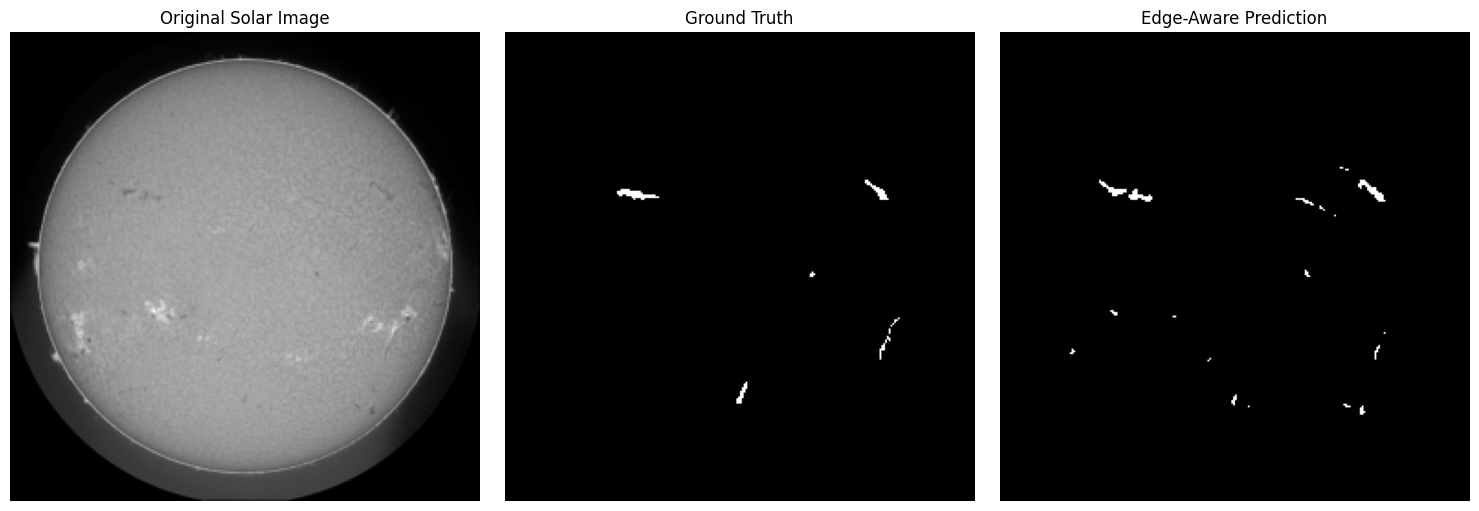

In [93]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

# Pick a random validation image
idx = random.randint(0, len(val_dataset) - 1)

image, mask = val_dataset[idx]

# Model prediction
improved_model.eval()

with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = improved_model(input_tensor)
    probability = torch.sigmoid(output)
    prediction = (probability > 0.7).float()

# Convert to numpy
image_np = image.squeeze().numpy()
mask_np = mask.squeeze().numpy()
prediction_np = prediction.squeeze().cpu().numpy()

# Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np, cmap="gray")
plt.title("Original Solar Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction_np, cmap="gray")
plt.title("Edge-Aware Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

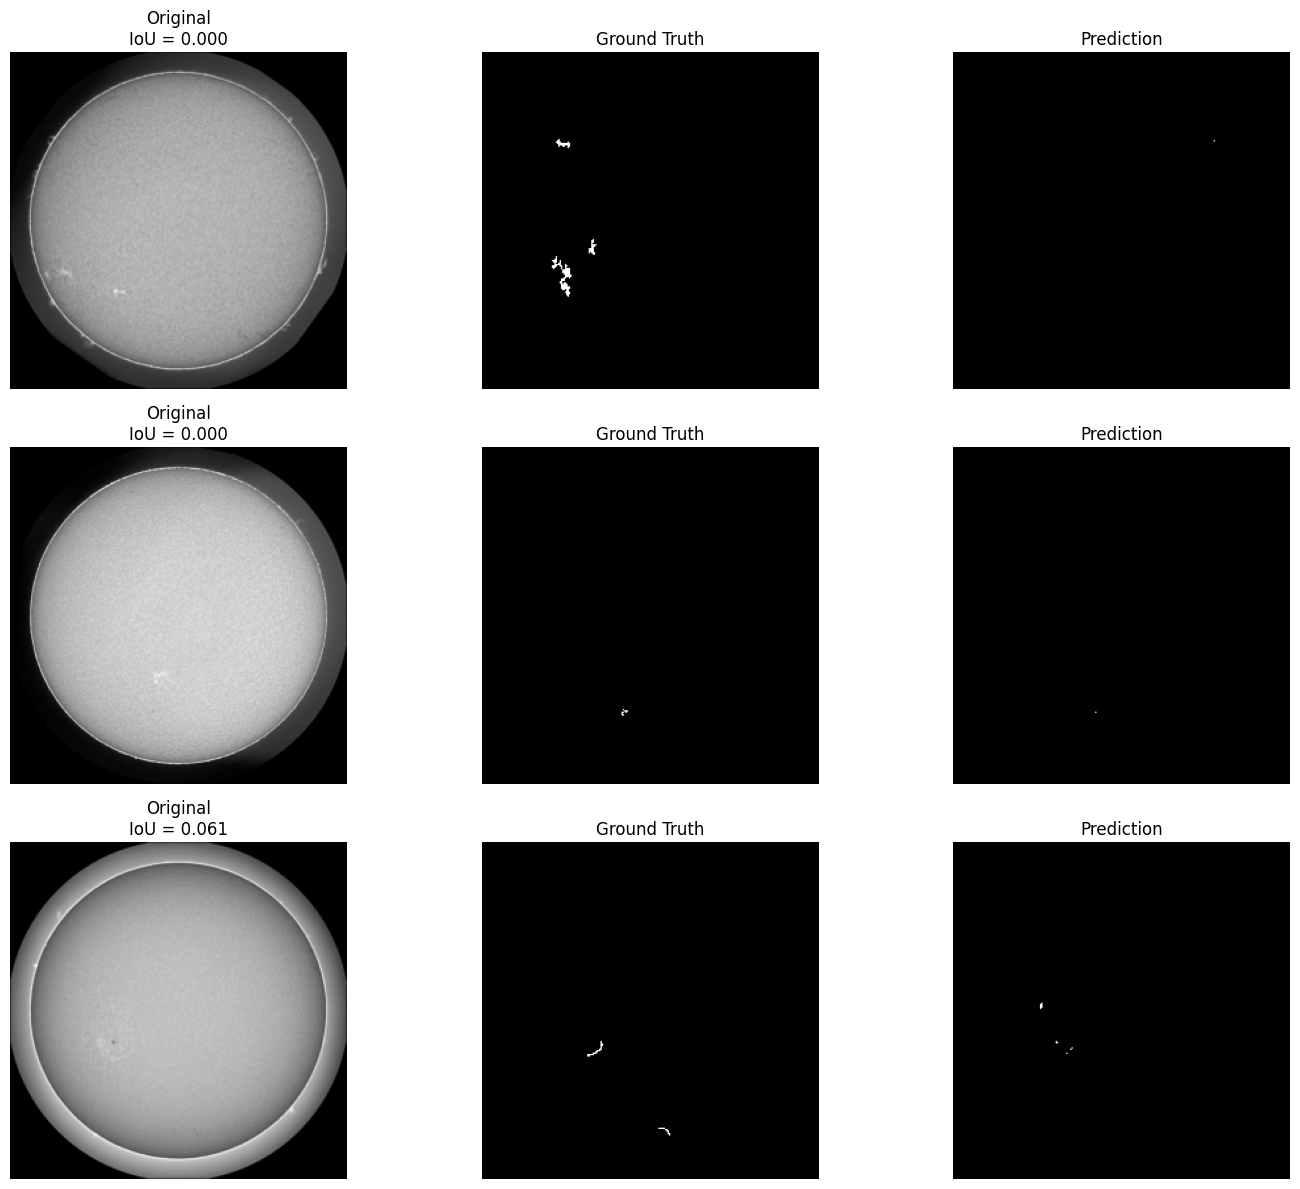

In [94]:
import matplotlib.pyplot as plt
import torch
import numpy as np

improved_model.eval()

failure_cases = []

with torch.no_grad():
    for idx in range(len(val_dataset)):
        image, mask = val_dataset[idx]

        output = improved_model(
            image.unsqueeze(0).to(device)
        )

        probability = torch.sigmoid(output)
        prediction = (probability > 0.7).float()

        # Calculate IoU for this image
        pred = prediction.squeeze().cpu().numpy()
        gt = mask.squeeze().numpy()

        intersection = np.logical_and(pred == 1, gt == 1).sum()
        union = np.logical_or(pred == 1, gt == 1).sum()

        iou = intersection / (union + 1e-8)

        failure_cases.append((iou, image.numpy().squeeze(), gt, pred))

# Sort from worst to best
failure_cases.sort(key=lambda x: x[0])

# Display 3 worst cases
plt.figure(figsize=(15, 12))

for i in range(3):
    iou, image, gt, pred = failure_cases[i]

    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Original\nIoU = {iou:.3f}")
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(pred, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()